In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.7 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

In [59]:
path = '/content/highway.webp'

In [60]:
cap = cv2.imread(path)

In [61]:
model = YOLO('yolov8n.pt')


0: 384x640 6 cars, 1 bus, 2 trucks, 9.1ms
Speed: 2.5ms preprocess, 9.1ms inference, 4.4ms postprocess per image at shape (1, 3, 384, 640)


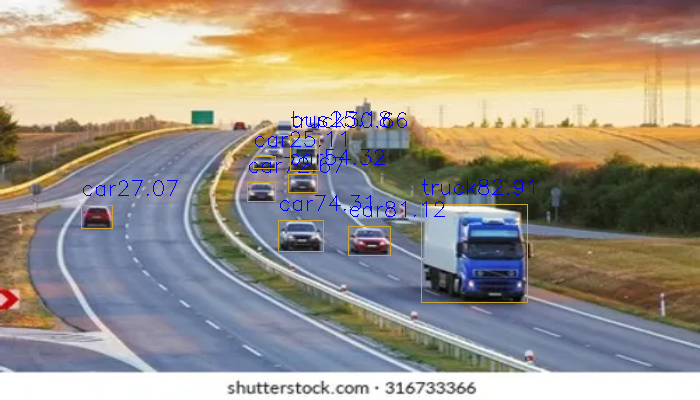

-1

In [63]:
frame = cv2.resize(cap,(700,400))

result = model(frame,stream=True)
for r in result:
  boxes = r.boxes
  for box in boxes:
   x1,y1,x2,y2 = box.xyxy[0].int().tolist()

   #confidence score
   conf = float(box.conf[0])
   conf = round(conf*100,2)

   #name the class
   cls = int(box.cls[0])
   lables = model.names[cls]

   #draw rectangle
   cv2.rectangle(frame,(x1,y1),(x2,y2),(49, 164, 202),1)

   #name the class and confidence score
   cv2.putText(frame,f'{lables}{conf}',(x1,max(20,y1-10)),cv2.FONT_HERSHEY_SIMPLEX,0.7,(255,0,0),1)
#show the frame
cv2_imshow(frame)
cv2.waitKey(0)